<a href="https://colab.research.google.com/github/Kalaiarasi2506/Python-training-Problems/blob/main/car_price_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
os.environ['KAGGLE_USERNAME']='kalai'
os.environ['KAGGLE_KEY']='KGAT_4e0c932ae0015ddd1e78b61763246409'

In [ ]:
!pip install kaggle

In [ ]:
!kaggle datasets download -d 'zafarali27/car-price-prediction'

Dataset URL: https://www.kaggle.com/datasets/zafarali27/car-price-prediction
License(s): ODC Public Domain Dedication and Licence (PDDL)
car-price-prediction.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
!unzip /content/car-price-prediction.zip

Archive:  /content/car-price-prediction.zip
replace car_price_prediction_.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [ ]:
import pandas as pd
df = pd.read_csv("/content/car-price-prediction.zip")
df.head(10)

,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
0,1,Tesla,2016,2.3,Petrol,Manual,114832,New,26613.92,Model X
1,2,BMW,2018,4.4,Electric,Manual,143190,Used,14679.61,5 Series
2,3,Audi,2013,4.5,Electric,Manual,181601,New,44402.61,A4
3,4,Tesla,2011,4.1,Diesel,Automatic,68682,New,86374.33,Model Y
4,5,Ford,2009,2.6,Diesel,Manual,223009,Like New,73577.10,Mustang
5,6,Audi,2019,2.4,Diesel,Automatic,246553,Like New,88969.76,Q7
6,7,Audi,2020,4.0,Electric,Automatic,135486,Used,63498.75,Q5
7,8,Tesla,2017,5.3,Hybrid,Automatic,83030,New,17381.19,Model Y
8,9,Honda,2023,5.7,Electric,Manual,120360,Like New,15905.62,Civic
9,10,Ford,2010,1.5,Electric,Automatic,135009,Like New,9560.22,Explorer


In [ ]:
df.tail(10)

,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
2490,2491,Audi,2018,2.4,Hybrid,Manual,146539,Used,98434.45,Q5
2491,2492,Toyota,2019,4.2,Hybrid,Manual,75955,New,28041.25,Prius
2492,2493,Tesla,2002,2.7,Petrol,Manual,147748,New,66352.03,Model X
2493,2494,Ford,2014,6.0,Diesel,Automatic,94791,New,33847.10,Focus
2494,2495,Mercedes,2001,2.3,Petrol,Manual,162586,Used,90378.98,E-Class
2495,2496,Audi,2020,2.4,Petrol,Automatic,22650,Like New,61384.10,Q5
2496,2497,Audi,2001,5.7,Hybrid,Manual,77701,Like New,24710.35,A3
2497,2498,Ford,2021,1.1,Hybrid,Manual,272827,Like New,29902.45,Fiesta
2498,2499,Audi,2002,4.5,Diesel,Manual,229164,Like New,46085.67,Q5
2499,2500,Toyota,2005,4.6,Diesel,Automatic,80978,Used,16594.14,RAV4


In [ ]:
print(len(df))
print(df.shape)

2500
(2500, 10)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Car ID        2500 non-null   int64  
 1   Brand         2500 non-null   object 
 2   Year          2500 non-null   int64  
 3   Engine Size   2500 non-null   float64
 4   Fuel Type     2500 non-null   object 
 5   Transmission  2500 non-null   object 
 6   Mileage       2500 non-null   int64  
 7   Condition     2500 non-null   object 
 8   Price         2500 non-null   float64
 9   Model         2500 non-null   object 
dtypes: float64(2), int64(3), object(5)
memory usage: 195.4+ KB


In [ ]:
df.describe()

,Car ID,Year,Engine Size,Mileage,Price
count,2500.00000,2500.0000,2500.000000,2500.000000,2500.000000
mean,1250.50000,2011.6268,3.465240,149749.844800,52638.022532
std,721.83216,6.9917,1.432053,87919.952034,27295.833455
min,1.00000,2000.0000,1.000000,15.000000,5011.270000
25%,625.75000,2005.0000,2.200000,71831.500000,28908.485000
50%,1250.50000,2012.0000,3.400000,149085.000000,53485.240000
75%,1875.25000,2018.0000,4.700000,225990.500000,75838.532500
max,2500.00000,2023.0000,6.000000,299967.000000,99982.590000


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.dtypes

,0
Car ID,int64
Brand,object
Year,int64
Engine Size,float64
Fuel Type,object
Transmission,object
Mileage,int64
Condition,object
Price,float64
Model,object


In [ ]:
print(df.columns)

Index(['Car ID', 'Brand', 'Year', 'Engine Size', 'Fuel Type', 'Transmission',
       'Mileage', 'Condition', 'Price', 'Model'],
      dtype='object')


In [ ]:
print(df['Brand'])

0        Tesla
1          BMW
2         Audi
3        Tesla
4         Ford
         ...  
2495      Audi
2496      Audi
2497      Ford
2498      Audi
2499    Toyota
Name: Brand, Length: 2500, dtype: object


In [ ]:
df.isnull().sum()

,0
Car ID,0
Brand,0
Year,0
Engine Size,0
Fuel Type,0
Transmission,0
Mileage,0
Condition,0
Price,0
Model,0


In [ ]:
df = df.drop('Car ID', axis=1)

In [ ]:
df['Car_Age'] = 2025 - df['Year']

In [ ]:
print(df.columns)

Index(['Brand', 'Year', 'Engine Size', 'Fuel Type', 'Transmission', 'Mileage',
       'Condition', 'Price', 'Model', 'Car_Age'],
      dtype='object')


In [ ]:
df.drop(['Year'], axis=1, inplace=True)

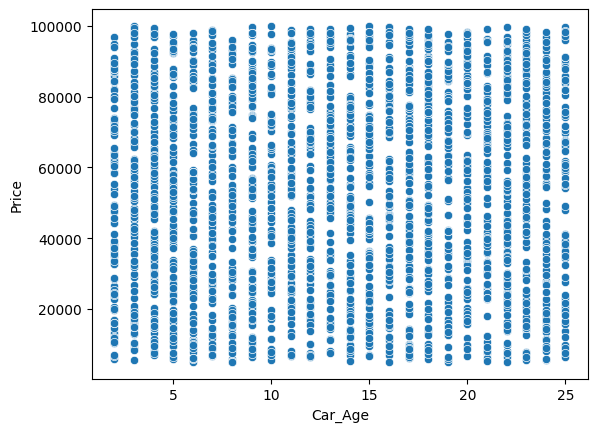

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.scatterplot(x='Car_Age', y='Price', data=df)
plt.show()

In [ ]:
df.select_dtypes(include='object').columns

Index(['Brand', 'Fuel Type', 'Transmission', 'Condition', 'Model'], dtype='object')

In [ ]:
df = pd.get_dummies(df, drop_first=True)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [ ]:
X = df.drop('Price', axis=1)
y = df['Price']

In [ ]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)
print("Model trained")
y_pred = model.predict(X_test)

Model trained


In [ ]:

print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 23877.14311881313
MSE: 772529400.9041506
RMSE: 27794.413123938248
R2 Score: -0.019768995768368436


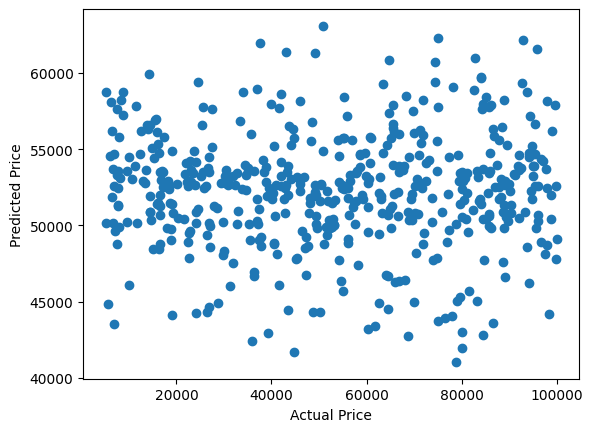

In [ ]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.show()

In [ ]:
print(df.columns)
print(df.shape)

Index(['Engine Size', 'Mileage', 'Price', 'Car_Age', 'Brand_BMW', 'Brand_Ford',
       'Brand_Honda', 'Brand_Mercedes', 'Brand_Tesla', 'Brand_Toyota',
       'Fuel Type_Electric', 'Fuel Type_Hybrid', 'Fuel Type_Petrol',
       'Transmission_Manual', 'Condition_New', 'Condition_Used',
       'Model_5 Series', 'Model_A3', 'Model_A4', 'Model_Accord',
       'Model_C-Class', 'Model_CR-V', 'Model_Camry', 'Model_Civic',
       'Model_Corolla', 'Model_E-Class', 'Model_Explorer', 'Model_Fiesta',
       'Model_Fit', 'Model_Focus', 'Model_GLA', 'Model_GLC', 'Model_Model 3',
       'Model_Model S', 'Model_Model X', 'Model_Model Y', 'Model_Mustang',
       'Model_Prius', 'Model_Q5', 'Model_Q7', 'Model_RAV4', 'Model_X3',
       'Model_X5'],
      dtype='object')
(2500, 43)
